# Practical Session 2 — Spectral density estimation and periodogram

We aim to estimate the power spectral density (PSD) of a real, zero-mean, weakly stationary process $X_t$. We observe $X_t$ for $t \in \{0,1,\dots,n-1\}$ and will use the FFT (DFT implementation) from numpy.fft. Recall that the PSD $f_X(\lambda)$ is the DTFT ( Discrete Time Fourier Transform) of the autocovariance $\gamma(h)$:

$$f_X(\lambda)=\frac{1}{2\pi}\sum_{h\in\mathbb{Z}}\gamma(h)\,e^{-i\lambda h}.$$

For this exercise you will complete code to compute the periodogram and relate it to the empirical autocovariance.

[✍️]=write-up LaTeX or on paper, [💻]=implement with ``python``

1) [✍️] Define the sample mean $\hat\mu_n=\frac{1}{n}\sum_{t=0}^{n-1}X_t$. For $h\ge 0$, define the empirical ACF estimator
$$\hat\gamma_n(h)=
\begin{cases}
\frac{1}{n}\sum_{t=0}^{n-1-h}\big(X_t-\hat\mu_n\big)\big(X_{t+h}-\hat\mu_n\big), & h<n,\\[4pt]
0, & h\ge n,
\end{cases}$$
$\quad\quad$ and for $h<0$ set $\hat\gamma_n(h)=\hat\gamma_n(|h|)$ (real process). Define the periodogram
$$I_n(\lambda)=\frac{1}{2\pi}\sum_{h=-\,n+1}^{n-1}\hat\gamma_n(h)\,e^{-i\lambda h}.$$
$\quad\quad$ Express $I_n(\lambda)$ as a function of the DTFT of the centered data $X_t-\hat\mu_n$.
    
2) [💻] Discrete grid computation.
Deduce an algorithm to compute $I_n\!\left(\frac{2\pi k}{m}\right)$ for $k=0,\dots,m-1$, where $m\ge n$ is the DFT length. Test it on the processes from Practical Session 1.

3) [✍️💻] Recovering $\hat\gamma_n(h)$ from $I_n$.
How can you obtain $\hat\gamma_n(h)$ from the discrete set $I_n\!\left(\frac{2\pi k}{m}\right)$? Which choice of m makes the relation simple (hint: zero-padding to avoid circular wrap-around)? Verify that your implementation matches a reference autocovariance routine.

4) [💻] White-noise variance experiment.
For white noise, estimate the variance of the periodogram for several n and draw conclusions. (Expected: large variance that does not vanish with n unless you smooth/average.)  

1. [✍️ Answer] : [A COMPLETER]

We have :
$$I_n(\lambda)=\frac{1}{2\pi}\sum\limits_{h=-n+1}^{n-1} \hat{\gamma}(h)e^{-i\lambda h}=\frac{1}{2\pi n}\sum\limits_{h=-n+1}^{n-1} \sum\limits_{t=0}^{n-1-|h|} (X_t-\mu_n)(X_{t+|h|}-\mu_n)e^{-i\lambda h} \quad (1)$$

$$|DFT(X_n-\mu_n)|^2=|\sum\limits_{t=0}^{n-1}(X_t-\mu_n)|^2=\sum\limits_{t=0}^{n-1}\sum\limits_{h=0}^{n-1}(X_t-\mu_n)(X_h-\mu_n)e^{-i\lambda (t-h)}$$
Let's take the following variables : $t$ and $h=t-h$, we will have : $-n+1\leq h \leq n-1$ and $t$, so we have :
$$|DFT(X_n-\mu_n)|^2=\sum\limits_{h=-n+1}^{n-1}\sum\limits_{t \in \mathcal{T}}(X_t-\mu_n)(X_{t-h}-\mu_n)e^{-i\lambda h}$$
Let's determine $\mathcal{T}$ :
- If $h \geq 0$ : 
$\left\{\begin{array}{l}
0 \leq t \leq n-1 \\
0 \leq t-h \leq n-1
\end{array}
\right.
$ $\Rightarrow$ $h \leq t \leq n-1$ $\Rightarrow$ $\mathcal{T}=[h,n-1] \cap \mathbb{N}$

$$\sum\limits_{h=0}^{n-1}\sum\limits_{t =h}^{n-1}(X_t-\mu_n)(X_{t-h}-\mu_n)e^{-i\lambda h} \overset{t'=t-h}{=}\sum\limits_{h=0}^{n-1}\sum\limits_{t =0}^{n-1-h}(X_t-\mu_n)(X_{t+h}-\mu_n)e^{-i\lambda h}$$

- If $h<0$ :
$\left\{\begin{array}{l}
0 \leq t \leq n-1 \\
0 \leq t-h \leq n-1
\end{array}
\right.
$ $\Rightarrow$ $0 \leq t \leq n-1+h=n-1-|h|$ $\Rightarrow$ $\mathcal{T}=[0,n-1-|h|] \cap \mathbb{N}$
$$\sum\limits_{h=-n+1}^{-1}\sum\limits_{t =0}^{n-1-|h|}(X_t-\mu_n)(X_{t-h}-\mu_n)e^{-i\lambda h}=\sum\limits_{h=-n+1}^{-1}\sum\limits_{t =0}^{n-1-|h|}(X_t-\mu_n)(X_{t+|h|}-\mu_n)e^{-i\lambda h}$$

So : $$|DFT(X_n-\mu_n)|^2=\sum\limits_{h=-n+1}^{n-1}\sum\limits_{t =0}^{n-1-|h|}(X_t-\mu_n)(X_{t+|h|}-\mu_n)e^{-i\lambda h} \quad (2)$$

From (1) and (2) we conclude that :
$$I_n(\lambda)=\frac{1}{2\pi n}|DFT(X_n-\mu_n)|^2$$



In [1]:
# Imports & helpers
# - center(x): enforce zero-mean data X_t - mu_hat
# - empirical_autocov: recall the empirical autocovariance

import numpy as np
import matplotlib.pyplot as plt

def center(x):
    x = np.asarray(x, dtype=float)
    return x - x.mean()

def empirical_autocov(x, h_max=None):
    # TODO ...
    T = len(x)
    if h_max == None:
        h_max = T-1
    gamma = np.zeros(h_max+1)
    mu = (1/T)*sum(x)
    for h in range(h_max+1):
        gamma[h]=sum([(x[t+h]-mu)*(x[t]-mu) for t in range(1,T-h)])/T
    return gamma

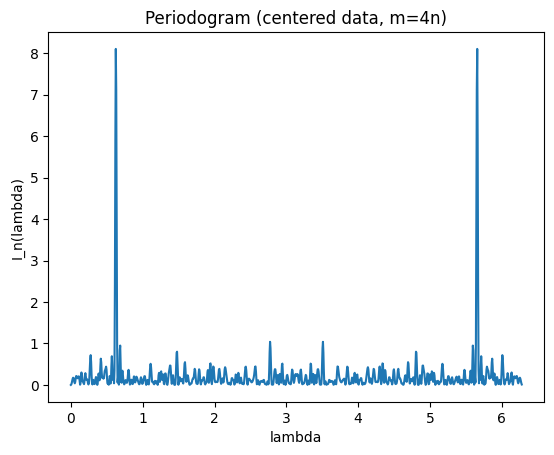

In [2]:
# (Task 2) Periodogram on a discrete grid via FFT
# I_n(λ_k) = |DFT(X - mu_hat, m)(k)|^2 / (2π n), where λ_k = 2πk/m.
# Implement and test on data from Practical Session 1

def periodogram_fft_centered(x, m=None):
    """
    Compute periodogram on the FFT grid for centered data.
    Args:
      x: 1D array, shape (n,)
      m: FFT length (>= n). If None, uses m = n.
    Returns:
      lam: array of λ_k = 2πk/m, k=0..m-1
      I:   I_n(λ_k)
      X:   FFT values for potential reuse
    """
    x = center(np.asarray(x, dtype=float))
    n = x.size
    if m is None:
        m = n
    X = np.fft.fft(x)
    lam = [2*np.pi*k/m for k in range(m)]
    I = np.array([1/(2*np.pi*n)*abs((sum([x[i]*np.exp(-lam[k] * 1j* i) for i in range(n)])**2)) for k in range(m)])# TODO ...
    return lam, I, X

# ==============
# ---- Demo ----
# ================
n = 256
x = np.cos(2*np.pi*0.1*np.arange(n)) + np.random.normal(0, 1, n)

lam, I, _ = periodogram_fft_centered(x, m=4*n)
# Plot
plt.figure()
plt.plot(lam, I)
plt.xlabel("lambda")
plt.ylabel("I_n(lambda)")
plt.title("Periodogram (centered data, m=4n)")
plt.show()

# ===================================================
# TODO: Replace x with your Practical Session 1 series,
# e.g. x = your_series_array
# ===================================================

In [5]:
# (Task 3) Recover γ̂_n(h) from I_n via IDFT of |FFT|^2
# Theory: with zero-padding m >= 2n - 1, circular correlation equals linear correlation
# Practice: implement and verify against a direct empirical ACF.

def acov_from_periodogram_via_idft(x, m=None, n_max=None):
    """
    Compute γ̂_n(h) from IDFT(|FFT|^2) with adequate zero-padding.
    Args:
      x: data (1D array)
      m: FFT length; if None, use next power of 2 >= 2n-1
    Returns:
      acov: γ̂_n (1D array)
      m:    FFT length actually used
    """
    x = center(np.asarray(x, dtype=float))
    n = x.size
    # TODO ...
    if m == None:
        m = 2**(int(np.log2(2*n-1))+1)
    X = np.fft.fft(x,n=m)# TODO ...
    r_circ = np.fft.ifft(np.abs(X)**2)# TODO ...
    if n_max is None:
       n_max = n
    acov = (1/n)*r_circ[:n]# TODO ...
    return acov, m

# ---- Verification against direct computation ----
acov_fft, m_used = acov_from_periodogram_via_idft(x)
acov_emp = empirical_autocov(x, h_max=len(acov_fft)-1)
print("m used:", m_used)
print("max |diff| =", np.max(np.abs(acov_fft - acov_emp)))

m used: 512
max |diff| = 0.00924713941682348


In [29]:
# (Task 3+) Reconstruct periodogram from γ̂_n to check the Fourier pair
# I_n(λ) = (1/2π) * sum_{h=-(n-1)}^{n-1} γ̂_n(h) e^{-iλh}

def periodogram_from_acov(acov, m):
    """
    Given acov[0..n-1], build symmetric sequence and FFT to sample I_n at λ_k = 2πk/m.
    """
    n = len(acov)
    g_sym = np.concatenate([acov, acov[1:][::-1]])  # length 2n-1
    if m < len(g_sym):
        raise ValueError("m must be >= 2n-1")
    G = np.fft.fft(g_sym, n=m)
    I = 1/(2*np.pi)*G
    lam = [2*np.pi*k/m for k in range(m)]# TODO ...
    return lam, I

# ---- Consistency check: direct periodogram vs acov->periodogram ----
m = 2048
lam1, I1, _ = periodogram_fft_centered(x, m=m)
acov, _ = acov_from_periodogram_via_idft(x, m=m, n_max=n)
lam2, I2 = periodogram_from_acov(acov, m=m)
print("grid equal:", np.allclose(lam1, lam2))
rmse = np.sqrt(np.mean((I1 - I2)**2))
print("RMSE between two routes:", rmse)

grid equal: True
RMSE between two routes: (5.384769853383275e-08+3.209556805783699e-08j)


In [69]:
# (Task 4) White noise periodogram
# White-noise variance experiment.
# For white noise, estimate the variance of the periodogram for several n and draw conclusions.
n_wn_values = [64, 128, 256, 1024]
sigma = 1.0
f = (sigma**2)/(2*np.pi)
print(f"The density of X for sigma={sigma} is : {f}")
print(f"The density of X squared for sigma={sigma} is : {f**2}")
for n_wn in n_wn_values:
    I_wn = []; m=0
    for op in range(50):
        x_WN = np.random.normal(0, sigma, n_wn)
        lam_wn, I_wn_op, _ = periodogram_fft_centered(x_WN)
        m=len(lam_wn)
        I_wn.append(I_wn_op)
    f_x_squared = (f)**2 * np.ones(m)
    variances = np.var(I_wn, axis=0, ddof=0) # variance per lambda_k
    print(f"For n = {n_wn} : ---------------------------------")
    print(f"The mean of the variance (per each lambda_k) : {np.mean(variances)}")

The density of X for sigma=1.0 is : 0.15915494309189535
The density of X squared for sigma=1.0 is : 0.025330295910584447
For n = 64 : ---------------------------------
The mean of the variance (per each lambda_k) : 0.022961432251624503
For n = 128 : ---------------------------------
The mean of the variance (per each lambda_k) : 0.02489718448179249
For n = 256 : ---------------------------------
The mean of the variance (per each lambda_k) : 0.024204861731680384
For n = 1024 : ---------------------------------
The mean of the variance (per each lambda_k) : 0.025523256755307547


We tried to estimate the variance of the periodogram :
- We find out that as $n$ grows, the periodogram gets closer to $f_X(\lambda)^2=\frac{\sigma^2}{2\pi}$.
So we can conclude that $I_n(\lambda) \underset{n\rightarrow +\infty}{\rightarrow}f_X(\lambda)^2$
